<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


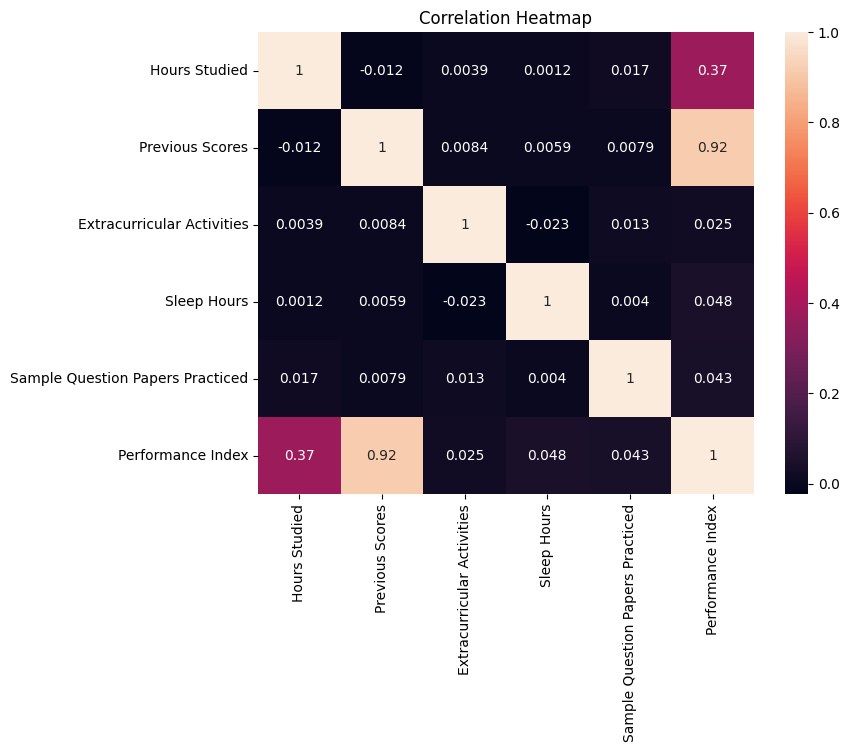

Coefficients: [2.85248393 1.0169882  0.60861668 0.47694148 0.19183144]
Intercept: -33.921946215556126
R2 Score: 0.9889832909573145
MSE: 4.082628398521853
RMSE: 2.0205515085050054
      Actual  Predicted
6252    51.0  54.711854
4684    20.0  22.615513
1731    46.0  47.903145
4742    28.0  31.289767
4521    41.0  43.004570


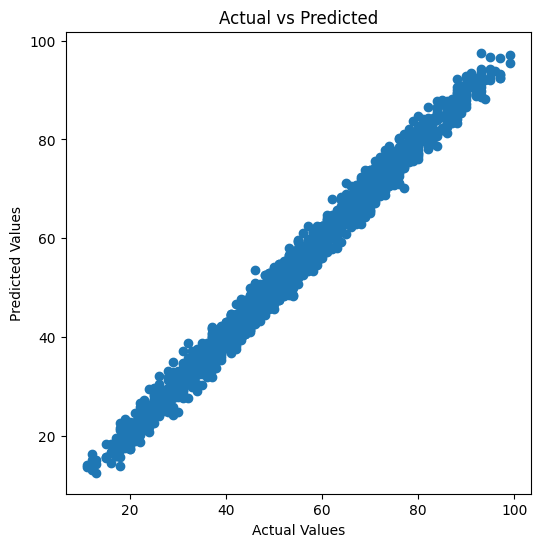

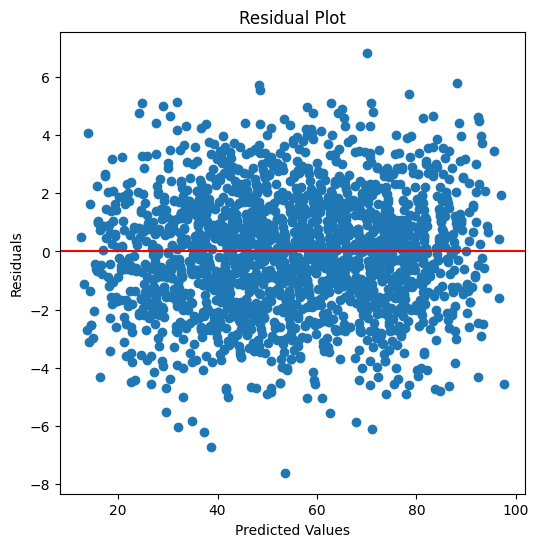

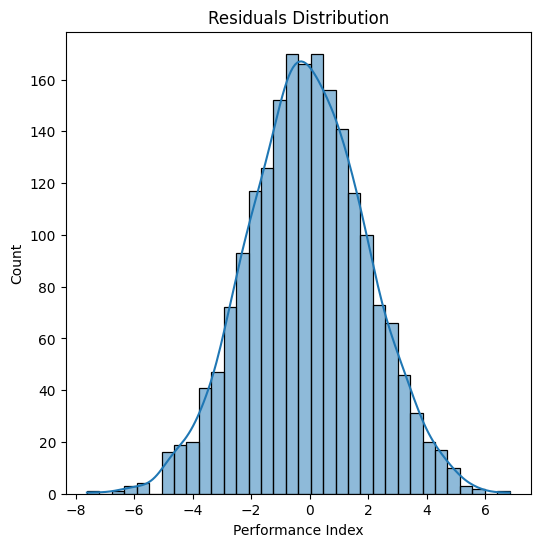

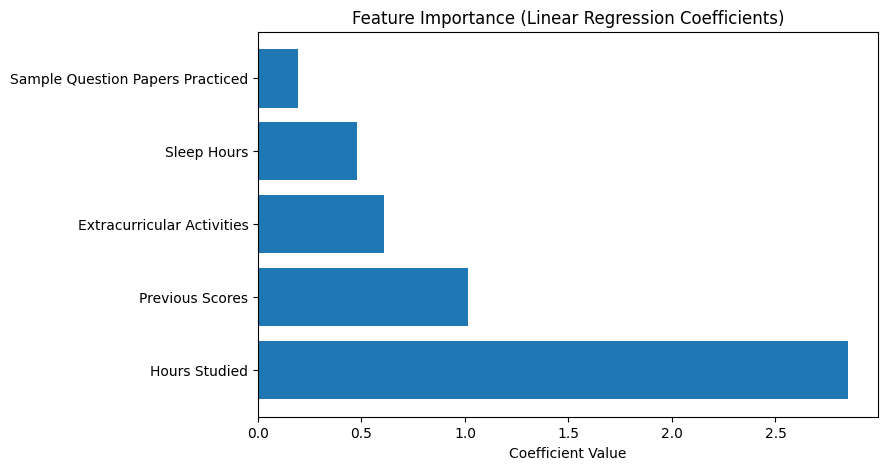

In [42]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ----------------------
# 1. Load Data
# ----------------------
df = pd.read_csv("Student_Performance.csv")

# ----------------------
# 2. Basic Info
# ----------------------
df.info()
df.describe()
df.isnull().sum()

# ----------------------
# 3. Encoding
# ----------------------
df["Extracurricular Activities"] = df[
    "Extracurricular Activities"
].map({
    "Yes": 1,
    "No": 0
})

df.head()

# ----------------------
# 4. EDA (Optional Heatmap)
# ----------------------
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# ----------------------
# 5. Features & Target
# ----------------------
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

# ----------------------
# 6. Train Test Split
# ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------
# 7. Model Training
# ----------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# ----------------------
# 8. Prediction
# ----------------------
y_pred = model.predict(X_test)

# ----------------------
# 9. Evaluation Metrics
# ----------------------
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

# ----------------------
# 10. Results Table
# ----------------------
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head())

# =====================================================
# 🔥 FINAL VISUALIZATIONS (IMPORTANT PART)
# =====================================================

# ----------------------
# 11. Actual vs Predicted
# ----------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

# ----------------------
# 12. Residuals
# ----------------------
residuals = y_test - y_pred

# Residual Plot
plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# ----------------------
# 13. Distribution of Errors
# ----------------------
plt.figure(figsize=(6,6))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# ----------------------
# 14. Feature Importance (Coefficients)
# ----------------------
plt.figure(figsize=(8,5))
plt.barh(X.columns, model.coef_)
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()